In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [8]:
movies = pd.read_csv("movies.dat", sep="::", engine="python",
                     names=["movie_id", "title", "genres"],
                     encoding="latin-1")
ratings=pd.read_csv("ratings.dat",sep="::",engine="python",
                    names=["user_id","movie_id","rating","timestamp"],
                    encoding="latin-1")
users=pd.read_csv("users.dat",sep="::",engine="python",
                  names=["user_id","gender","age","occupation","zip_code"],
                  encoding="latin-1")


In [11]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Users:", users.shape)


Movies: (3883, 3)
Ratings: (1000209, 4)
Users: (6040, 5)


In [19]:
print(movies.isnull().sum())
print(ratings.isnull().sum())
print(users.isnull().sum())


movie_id    0
title       0
genres      0
dtype: int64
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64
user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64


**Rating:**

In [12]:
ratings.describe()


,user_id,movie_id,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


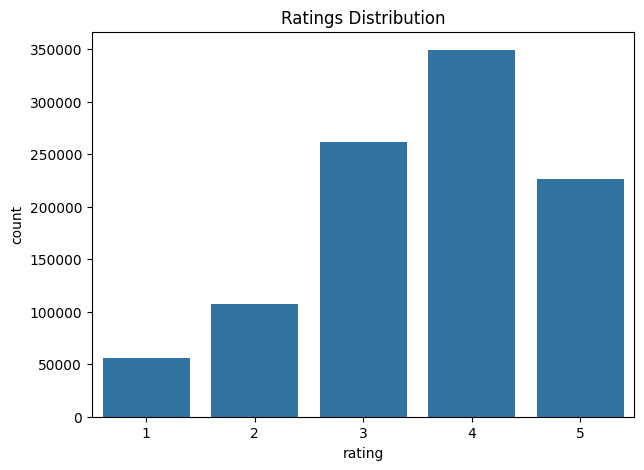

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(x="rating", data=ratings)
plt.title("Ratings Distribution")
plt.show()

In [14]:
user_Activity = ratings.groupby('user_id').size()
user_Activity.describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

In [16]:
movie_popularity = ratings.groupby('movie_id').size()
movie_popularity.describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64

In [18]:
movie_popularity

movie_id
1       2077
2        701
3        478
4        170
5        296
        ... 
3948     862
3949     304
3950      54
3951      40
3952     388
Length: 3706, dtype: int64

In [20]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))
sparsity


0.9553163743776871

In [26]:
df = ratings.merge(movies, on="movie_id").merge(users, on="user_id")
df.head()

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zip_code
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067
